<a href="https://colab.research.google.com/github/DHung154/BaiTapTuan4/blob/main/Cau2_Autoencoder_CatDog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CÂU 2: AUTOENCODER — NHẬN DẠNG CAT vs DOG

> - **Cách A:** Dữ liệu do giảng viên cung cấp (thư mục `data/cat_dog/`)
> - **Cách B:** Dùng CIFAR10 subset (cat=label 3, dog=label 5) — chạy được ngay không cần data

## BƯỚC 1: Nạp thư viện

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, Sequential
import os, warnings
warnings.filterwarnings('ignore')
print('✅ Thư viện đã nạp xong! Keras:', keras.__version__)

✅ Thư viện đã nạp xong! Keras: 3.13.2


## BƯỚC 2: Nạp dữ liệu
### Cách A — Dữ liệu giảng viên cung cấp (ảnh thư mục)
Nếu có thư mục `data/cat_dog/cats/` và `data/cat_dog/dogs/`, chạy cell này.

In [ ]:
# ============================================================
# CÁCH A: Nạp từ thư mục ảnh do giảng viên cung cấp
# ============================================================
USE_TEACHER_DATA = False  # ← Đổi thành True nếu có data giảng viên

IMG_SIZE = 64  # resize ảnh về 64x64

if USE_TEACHER_DATA:
    from PIL import Image
    import glob

    def load_images(folder, label, img_size=IMG_SIZE):
        images, labels = [], []
        for path in glob.glob(os.path.join(folder, '*.jpg')) + \
                    glob.glob(os.path.join(folder, '*.png')):
            img = Image.open(path).convert('RGB').resize((img_size, img_size))
            images.append(np.array(img))
            labels.append(label)
        return np.array(images), np.array(labels)

    cat_imgs, cat_lbls = load_images('data/cat_dog/cats', 0)
    dog_imgs, dog_lbls = load_images('data/cat_dog/dogs', 1)

    images = np.concatenate([cat_imgs, dog_imgs], axis=0).astype('float32') / 255.0
    labels = np.concatenate([cat_lbls, dog_lbls], axis=0)

    # Shuffle
    idx = np.random.permutation(len(images))
    images, labels = images[idx], labels[idx]

    split = int(0.8 * len(images))
    x_train, x_test   = images[:split], images[split:]
    y_train, y_test   = labels[:split], labels[split:]
    class_names = ['Cat', 'Dog']
    print(f'✅ Nạp data giảng viên: train={len(x_train)}, test={len(x_test)}')
else:
    print('⏭️  Bỏ qua Cách A → dùng Cách B bên dưới')

### Cách B — Dùng CIFAR10 subset (cat=3, dog=5)

In [3]:
# ============================================================
# CÁCH B: Dùng CIFAR10 (cat=label 3, dog=label 5)
# ============================================================
USE_TEACHER_DATA = False # Added this line to define the variable if not already defined
if not USE_TEACHER_DATA:
    from keras.datasets import cifar10

    (X_all_train, Y_all_train), (X_all_test, Y_all_test) = cifar10.load_data()

    # Lọc chỉ lấy cat (3) và dog (5)
    def filter_cat_dog(X, Y):
        mask = (Y.flatten() == 3) | (Y.flatten() == 5)
        imgs = X[mask].astype('float32') / 255.0
        lbls = (Y[mask].flatten() == 5).astype(int)  # cat=0, dog=1
        return imgs, lbls

    x_train, y_train = filter_cat_dog(X_all_train, Y_all_train)
    x_test,  y_test  = filter_cat_dog(X_all_test,  Y_all_test)
    class_names = ['Cat', 'Dog']
    IMG_SIZE = 32

    print(f'✅ CIFAR10 Cat/Dog — train: {x_train.shape}, test: {x_test.shape}')
    print(f'   Phân phối train: Cat={np.sum(y_train==0)}, Dog={np.sum(y_train==1)}')


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✅ CIFAR10 Cat/Dog — train: (10000, 32, 32, 3), test: (2000, 32, 32, 3)
   Phân phối train: Cat=5000, Dog=5000


## BƯỚC 3: Hiển thị ảnh mẫu

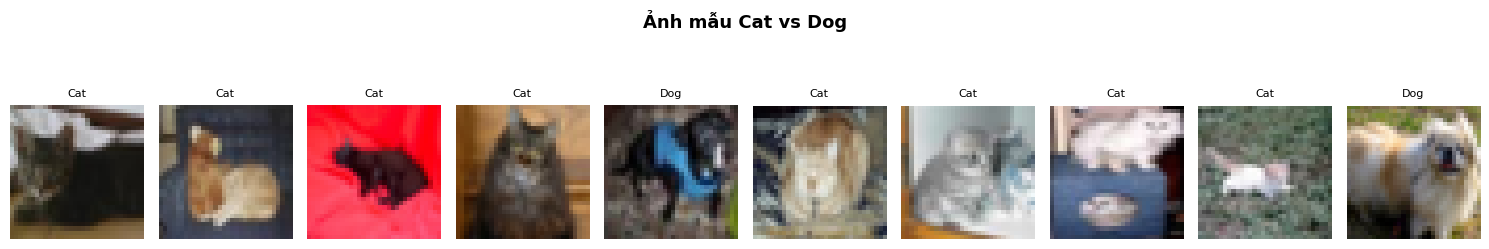

In [4]:
plt.figure(figsize=(15, 3))
plt.suptitle('Ảnh mẫu Cat vs Dog', fontsize=13, fontweight='bold')
for i in range(10):
    ax = plt.subplot(1, 10, i+1)
    img = x_train[i]
    if IMG_SIZE == 32:
        plt.imshow(img)
    else:
        plt.imshow(img)
    plt.title(class_names[y_train[i]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## BƯỚC 4: Tiền xử lý & Flatten

In [5]:
input_dim = int(np.prod(x_train.shape[1:]))  # 32*32*3 = 3072 hoặc 64*64*3 = 12288
x_train_flat = x_train.reshape(len(x_train), input_dim)
x_test_flat  = x_test.reshape(len(x_test),  input_dim)

print(f'input_dim = {input_dim}')
print(f'x_train_flat: {x_train_flat.shape}')
print(f'x_test_flat:  {x_test_flat.shape}')

input_dim = 3072
x_train_flat: (10000, 3072)
x_test_flat:  (2000, 3072)


## BƯỚC 5: Xây dựng Autoencoder

In [18]:

import keras
from keras import layers

# ── ENCODER ──
input_img = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)  # shape: (4,4,128)

# ── DECODER ──
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)
decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)  # shape: (32,32,3)

autoencoder = keras.Model(input_img, decoded, name='conv_autoencoder')
encoder     = keras.Model(input_img, encoded, name='conv_encoder')

autoencoder.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
print('✅ Conv Autoencoder xây dựng xong!')
autoencoder.summary()

✅ Conv Autoencoder xây dựng xong!


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## BƯỚC 6: Huấn luyện

In [19]:
## BƯỚC 6 (MỚI): Huấn luyện (dùng ảnh gốc 2D, không flatten)

history = autoencoder.fit(
    x_train, x_train,          # ← dùng x_train thay vì x_train_flat
    epochs=50,
    batch_size=64,
    shuffle=True,
    verbose=1,
    validation_data=(x_test, x_test)
)
print('\n✅ Huấn luyện xong!')

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 422ms/step - accuracy: 0.6379 - loss: 0.0260 - val_accuracy: 0.6659 - val_loss: 0.0136
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 418ms/step - accuracy: 0.6909 - loss: 0.0122 - val_accuracy: 0.7144 - val_loss: 0.0107
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 402ms/step - accuracy: 0.7294 - loss: 0.0104 - val_accuracy: 0.7251 - val_loss: 0.0095
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 401ms/step - accuracy: 0.7561 - loss: 0.0092 - val_accuracy: 0.7322 - val_loss: 0.0095
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 65s 412ms/step - accuracy: 0.7626 - loss: 0.0087 - val_accuracy: 0.7827 - val_loss: 0.0090
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 64s 408ms/step - accuracy: 0.7707 - loss: 0.0081 - val_accuracy: 0.7865 - val_loss: 0.0078
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 403ms/step - accuracy: 0.7757 - loss: 0.0076 - val_accuracy: 0.7882 - val_loss: 0.0073
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 401ms/step - accuracy: 0.7771 - loss: 0

## BƯỚC 7: Đồ thị đánh giá

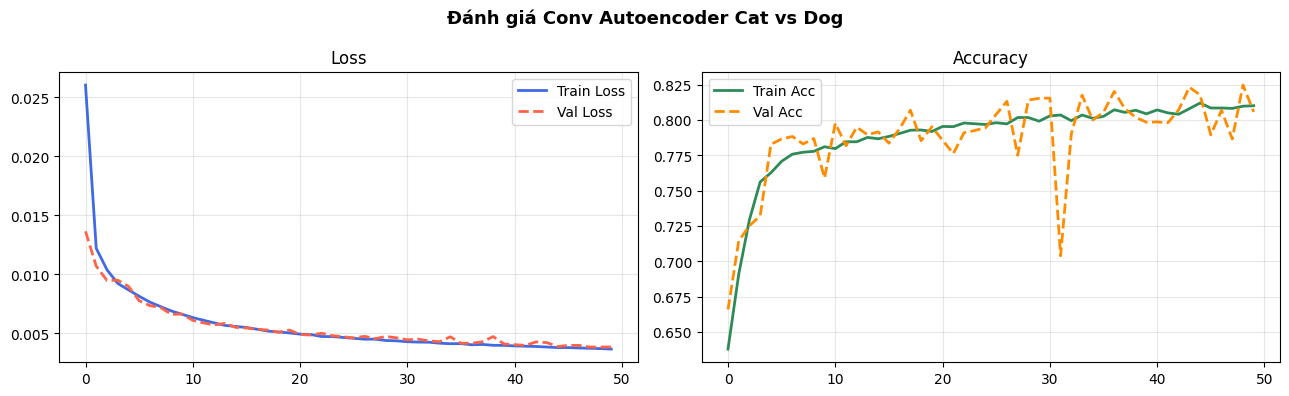

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Đánh giá Conv Autoencoder Cat vs Dog', fontsize=13, fontweight='bold')
axes[0].plot(history.history['loss'],     label='Train Loss', color='royalblue', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato',    lw=2, ls='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['accuracy'],     label='Train Acc', color='seagreen',   lw=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='darkorange', lw=2, ls='--')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## BƯỚC 8: Dự báo và hiển thị

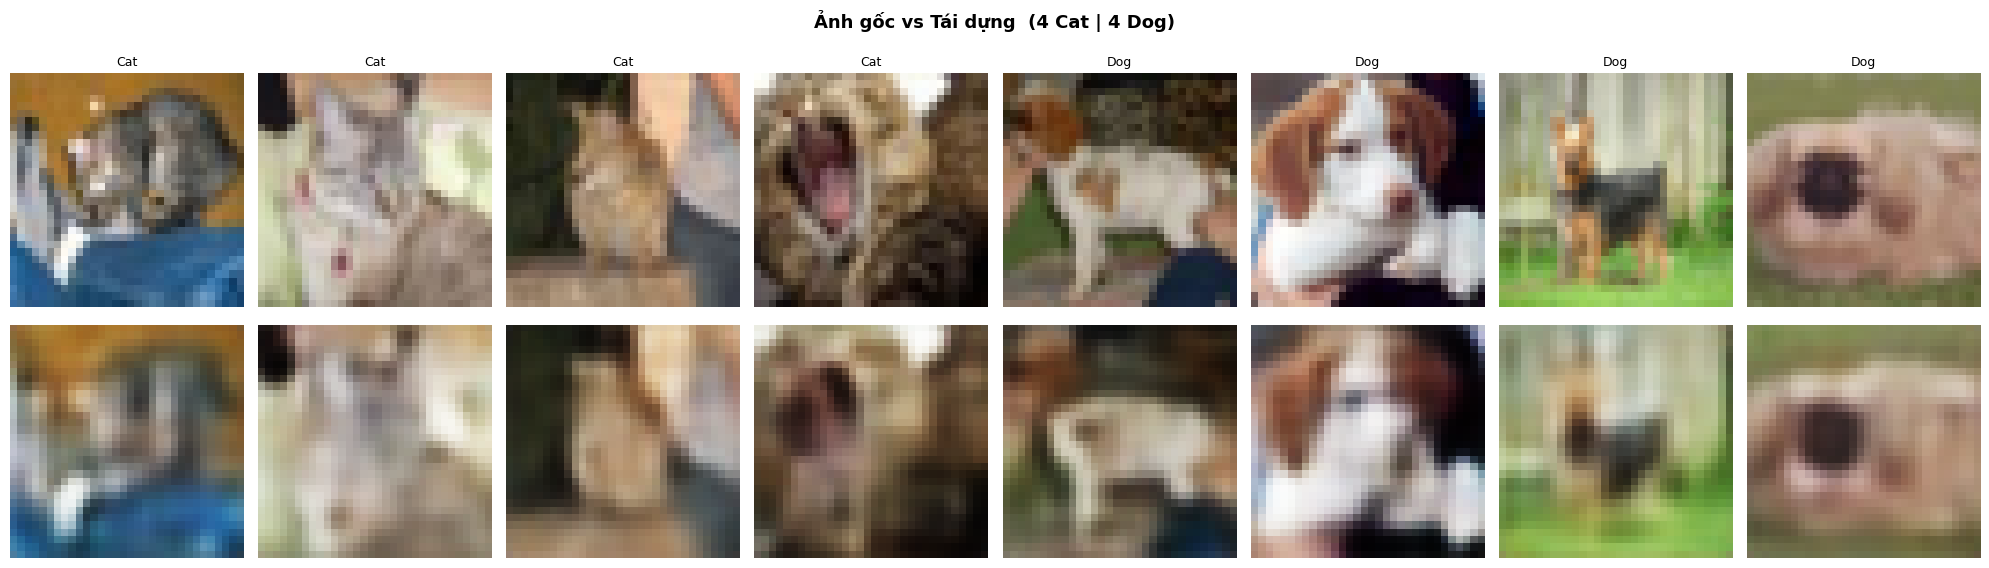

In [23]:
encoded_imgs = encoder.predict(x_test, verbose=0)
decoded_imgs = autoencoder.predict(x_test, verbose=0)

n = 8
# Lấy 4 cat và 4 dog
cat_idx = np.where(y_test == 0)[0][:4]
dog_idx = np.where(y_test == 1)[0][:4]
show_idx = np.concatenate([cat_idx, dog_idx])

fig, axes = plt.subplots(2, n, figsize=(20, 6))
fig.suptitle('Ảnh gốc vs Tái dựng  (4 Cat | 4 Dog)', fontsize=13, fontweight='bold')
for col, i in enumerate(show_idx):
    axes[0, col].imshow(np.clip(x_test[i], 0, 1))
    axes[0, col].set_title(class_names[y_test[i]], fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(np.clip(decoded_imgs[i], 0, 1))
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('Gốc',      fontsize=10, rotation=0, labelpad=45, va='center')
axes[1, 0].set_ylabel('Tái dựng', fontsize=10, rotation=0, labelpad=45, va='center')
plt.tight_layout(); plt.show()

## BƯỚC 9: Đánh giá MSE theo Cat/Dog

In [25]:
mse_per = np.mean((x_test - decoded_imgs)**2, axis=(1, 2, 3))
print('='*45)
print('   ĐÁNH GIÁ CHẤT LƯỢNG TÁI DỰNG')
print('='*45)
print(f'  MSE tổng    : {np.mean(mse_per):.6f}')
print(f'  PSNR        : {np.mean(-10*np.log10(mse_per+1e-10)):.2f} dB')
for lbl, name in enumerate(class_names):
    mask = y_test == lbl
    print(f'  MSE {name:<6} : {np.mean(mse_per[mask]):.6f}')

   ĐÁNH GIÁ CHẤT LƯỢNG TÁI DỰNG
  MSE tổng    : 0.003845
  PSNR        : 24.58 dB
  MSE Cat    : 0.003847
  MSE Dog    : 0.003842


⚙️ Đang train KNN trên latent space...
✅ KNN sẵn sàng!

📁 Chọn ảnh từ máy (jpg/png)...


Saving meo3.jpg to meo3 (2).jpg
Saving meo2.jpg to meo2 (1).jpg
Saving cho.jpg to cho (2).jpg
Saving meo.jpg to meo (3).jpg


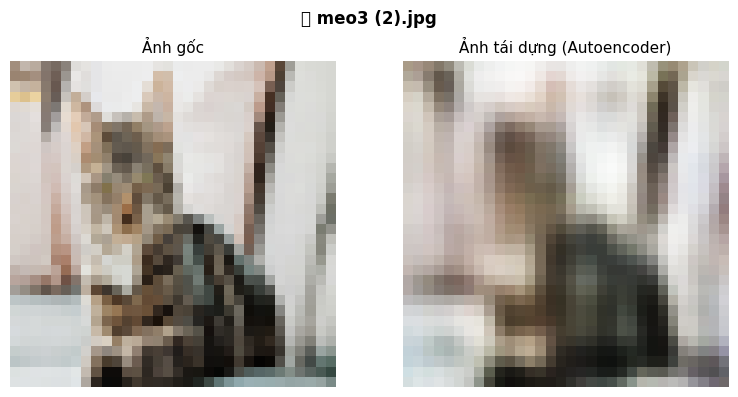

  MSE   : 0.007901
  PSNR  : 21.02 dB
  → Dự đoán: Dog (Cat: 40.0% | Dog: 60.0%)



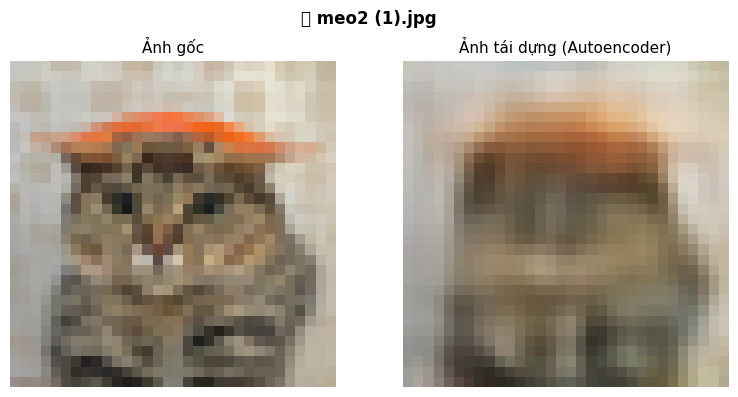

  MSE   : 0.005509
  PSNR  : 22.59 dB
  → Dự đoán: Dog (Cat: 20.0% | Dog: 80.0%)



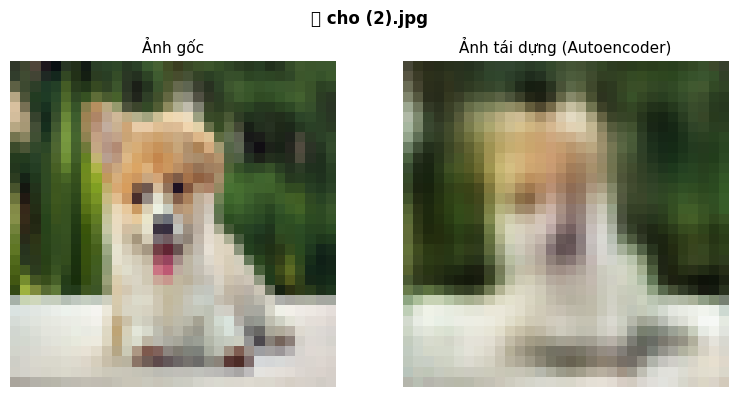

  MSE   : 0.006394
  PSNR  : 21.94 dB
  → Dự đoán: Dog (Cat: 0.0% | Dog: 100.0%)



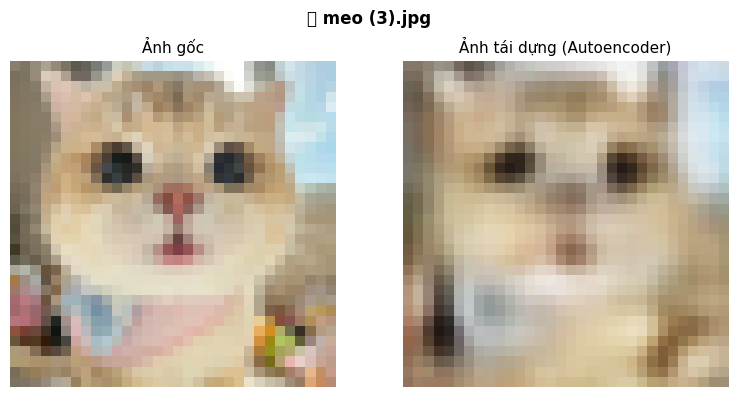

  MSE   : 0.004989
  PSNR  : 23.02 dB
  → Dự đoán: Cat (Cat: 60.0% | Dog: 40.0%)



In [29]:
## BƯỚC 10: Upload ảnh từ máy để test (dùng KNN trên latent space)

from google.colab import files
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
import io

# ── Train KNN 1 lần trên encoded features ──
print("⚙️ Đang train KNN trên latent space...")
# Use unflattened x_train for convolutional encoder
encoded_train = encoder.predict(x_train, verbose=0)
# Flatten the encoded output for KNN classifier
encoded_train_flat_for_knn = encoded_train.reshape(encoded_train.shape[0], -1)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(encoded_train_flat_for_knn, y_train)
print("✅ KNN sẵn sàng!\n")

# ── Upload & predict ──
print("📁 Chọn ảnh từ máy (jpg/png)...")
uploaded = files.upload()

for filename, content in uploaded.items():
    # Đọc và xử lý ảnh
    img = Image.open(io.BytesIO(content)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img).astype('float32') / 255.0
    # Add batch dimension for model input (from (H,W,C) to (1,H,W,C))
    img_input_for_model = img_array[np.newaxis, ...]

    # Encode → Decode
    # Use encoder with 4D input
    encoded_out = encoder.predict(img_input_for_model, verbose=0)
    # Use autoencoder to reconstruct directly from original image
    decoded_out = autoencoder.predict(img_input_for_model, verbose=0)
    # decoded_out is (1, H, W, C), take the first image (H, W, C)
    decoded_img = decoded_out[0]

    # MSE: compare original 3D image with reconstructed 3D image
    mse = np.mean((img_array - decoded_img) ** 2)
    psnr = -10 * np.log10(mse + 1e-10)

    # KNN predict
    # Flatten encoded_out for KNN prediction
    encoded_out_flat_for_knn = encoded_out.reshape(1, -1)
    pred_label = knn.predict(encoded_out_flat_for_knn)[0]
    pred_proba = knn.predict_proba(encoded_out_flat_for_knn)[0]

    # Hiển thị
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f'📷 {filename}', fontsize=12, fontweight='bold')
    axes[0].imshow(np.clip(img_array, 0, 1))
    axes[0].set_title('Ảnh gốc', fontsize=11)
    axes[0].axis('off')
    axes[1].imshow(np.clip(decoded_img, 0, 1))
    axes[1].set_title('Ảnh tái dựng (Autoencoder)', fontsize=11)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    print(f'  MSE   : {mse:.6f}')
    print(f'  PSNR  : {psnr:.2f} dB')
    print(f'  → Dự đoán: {class_names[pred_label]} '
          f'(Cat: {pred_proba[0]:.1%} | Dog: {pred_proba[1]:.1%})')
    print()